# Rectified Image Processing for Thermal Landscapes Project
### Nkuhlu
 PB 6/23/22
 
Reads in rectified multiband thermal images from each site and looks for images that overlap with shapefiles of inside/outside the exclosures. Extracts metrics from thermal images for analysis.

##### Weird Things about Nkuhlu
- The shapefile has 3 columns for treatments: 
    - "Exclosure" which is either "Full"/"Partial"/"Open"
    - "TopoPositi" which is either "Upland"/"Lowland"
    - "Treatment" which is either "Inside"/"Outside"
    
### EDITED 8/9/22 To Only Include the Full and Open Exclosure.

In [3]:
import rasterio as rio
import numpy as np
import geopandas as gpd
from pathlib import Path
import xarray as xr
import rioxarray as rioxr
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import seaborn as sns

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 11})

# # # Define inputs

img_dir = Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal')
shp_f = Path('./data/in/Polygons_AD_current/Nkuhlu_polygon.shp')

# Set site/project string for output figures and stats
projstr = 'Nkuhlu'

# Set threshold of overlap tolerance btwn images
threshold = 0.25

# Set merged product dir for the project
# used for opening up CHM and other lidar data files
mergedprodstr = '2020-01-16_NkuluEP'

# # # END USER INPUTS

In [4]:
# # # Open up corresponding Lidar data file 

# Products - CHM, DTM
mpdir = Path(f'/n/davies_lab/Lab/data/products_merged/{mergedprodstr}/')

chmf = [t for t in mpdir.glob('./CHM/*025m*.tif')][0]

CHM = rioxr.open_rasterio(chmf,
                          parse_coordinates=True,
                          masked=True)

dtmf = [t for t in mpdir.glob('./DTM/*025m*.tif')][0]

DTM = rioxr.open_rasterio(dtmf,
                          parse_coordinates=True,
                          masked=True)

# Also, get PAI and Canopy Density Values from a diff folder
# Note, there's one folder per exclosure, 
# with multiple netcdf (.nc) and geotif files in there
# folders are named by TreatmentTopo (ex: "FullLowland"
# Note that they are netcdf files, so you need to call the variable when you open it
# https://rasterio.readthedocs.io/en/latest/topics/datasets.html
gridmetricdir = Path('/n/davies_lab/Lab/LabLidarScripts/data/out/test/nkhulu/grid_metrics')

# # #

# Load shapefile
shp = gpd.read_file(shp_f)

# Reproject Shapefile to 32736 (if it's not already)
shp = shp.to_crs('EPSG:32736')

# FILTER SHAPEFILE for only Full and Open - 8/9/22
shp = shp.loc[((shp.Exclosure == 'Full') | (shp.Exclosure == 'Open'))]

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 11})

# Set hue order for plotting
exclosure_hues=["Outside", "Inside"]
topo_hues = ["Upland", "Lowland"]

# NOTE: The below is discontinued as of 6/22/2022 -
# instead the code goes through all images that overlap multiple treatments
# And removes images based on the above overlap threshold
# Set number of images to consider for final image list 
# nimgs = 1000

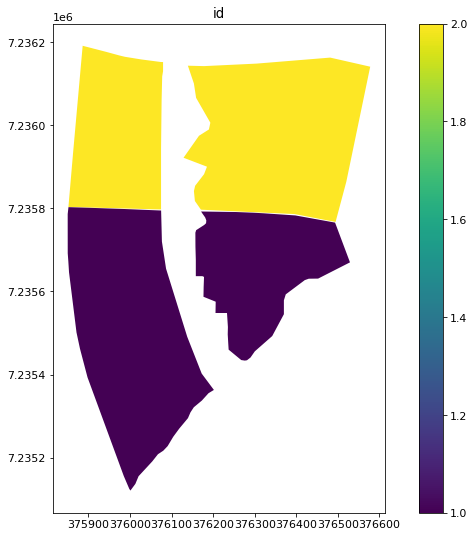

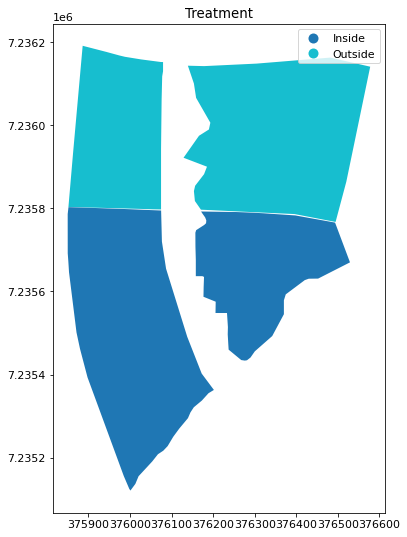

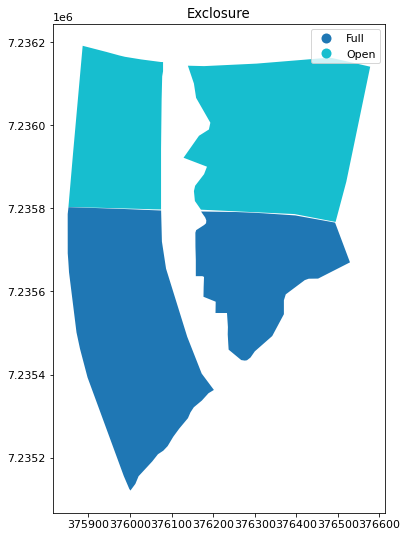

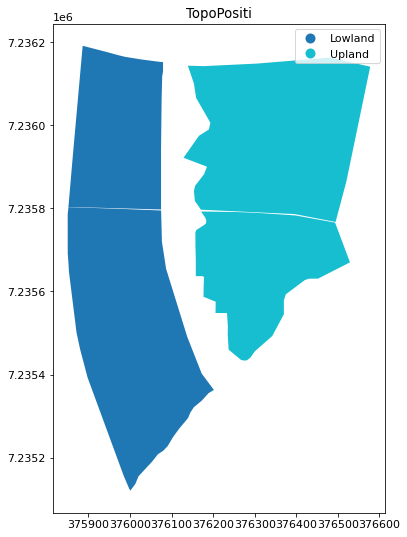

In [5]:
# Plot shapefile attributes
for c in shp.columns[0:-1]:
    shp.plot(column=c, legend=True)
    plt.title(c)
    plt.savefig(f'./figs/ShapefileFeatures_{c}_{projstr}.jpg', dpi=300)

In [6]:
# Define a simple evenness function
# compares the difference in coverage 
def evenness(x):
    # Filter for non-zero values
    X = x.loc[x>=0.01]
    # if more than 2:
    if len(X)>=2:
        # test difference between the values
        # This is the mean difference between the values
        # Divided by the sum of the values
        # 1 - is to make it an descending scale (higher values are better)
        # even = 1 - (np.mean(np.abs(np.diff((X)))) / np.sum(X))
        
        # Actually, screw that! Use coeff. of variation
         # NOTE: -1* need to rescale so scale is descending
        even = -1*(np.std(X)/np.mean(X))
    else:
        even = np.nan
    return even

### Step 1: Filter imglist to maximize overlap with polygon treatments

In [ ]:
# Make list of images to loop through
img_list = [i for i in img_dir.glob('*.tif')]

# for testing,reduce the list size
# img_list = img_list[0:100]

# Initialize list of img geometries
geom_list = []

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # warnings.filterwarnings(action='once')
    
    # Loop through each image
    for f in img_list:

        # Load image
        img = rioxr.open_rasterio(f,
                                  parse_coordinates=True,
                                  masked=True)

        # Get boundary polygon of the img for below filters
        minx, miny, maxx, maxy = img.rio.bounds()

        x_list = [minx, maxx,
                  maxx, minx,
                  minx]
        y_list = [maxy, maxy,
                  miny, miny,
                  maxy]

        # Make Boundary in to a Shapely Polygon, and save in a list
        geom_list.append(Polygon(zip(x_list, y_list)))

    # Make a Geodataframe from the result
    img_gdf = gpd.GeoDataFrame({'img':img_list, 'geometry':geom_list}, geometry='geometry', crs='EPSG:32736')

    # Use the shapefile to get the area overlap of each of the images and each of the treatments
    for ID, T, feat in zip(shp.index, shp.Treatment, shp.geometry.values):
        
        temp = img_gdf.geometry.apply(feat.intersection)

        # Save absolute area of overlap (not as useful as the percent overlap)
        img_gdf[f'Area {T} {ID}'] = temp.area

        # Save percent overlap with feature
        img_gdf[f'Overlap {T} {ID}'] = temp.area / feat.area
        
        warnings.filterwarnings(action='once')

    # Filter for area coverage
    # Note: If you do this with percent coverages, as oppossed to absolute area
    # you get images that overlap 
    # Compute the sum overlapping area percentages
    img_gdf['Sum'] = img_gdf.filter(like='Overlap').apply(np.nansum, axis=1)
    
    # Filter for area coverage
    # Note: If you do this with percent coverages, as oppossed to absolute area
    # you get images that overlap 
    # Compute the sum overlapping area percentages
    img_gdf['Evenness'] = img_gdf.filter(like='Overlap').apply(lambda x: evenness(x), axis=1)

    # Sort and redindex values in descending order of evenness, then summed percent overlap
    img_gdf.sort_values(by=['Evenness','Sum'], axis=0, inplace=True, ascending=False, ignore_index=True)
    

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

In [ ]:
# Keep only the images that overlap multiple treatments
# Cutoff is that img has to overlap at least 100 m2 
# img_gdf['OverlapsTreatments'] = img_gdf.filter(like='Area').apply(lambda x: np.sum(x>100) > 1, axis=1)
# img_gdf_filter = img_gdf.loc[img_gdf['OverlapsTreatments']]

# Keep only the images that overlap multiple treatments
# (Cutoff is that img has to overlap at least 1000 m2)
# Note: This cutoff can be tuned to each site.
# In some cases, you may want less images. In others, more.
# Edited 7/5/2022 to only count images that overlap both inside and outside,
# Discluding images that overlap 2 polygons, but both polygons are labelled as the same treatment.
areathres = 2000
img_gdf['OverlapsInside'] = img_gdf.filter(like='Area Inside').apply(lambda x: np.sum(x>areathres) > 0, axis=1)
img_gdf['OverlapsOutside'] = img_gdf.filter(like='Area Outside').apply(lambda x: np.sum(x>areathres) > 0, axis=1)
img_gdf_filter = img_gdf.loc[img_gdf['OverlapsInside'] & img_gdf['OverlapsOutside']]


# SPECIFIC TO NKULU
# added another filter here for pesky images that won't go
img_gdf_filter = img_gdf_filter.loc[img_gdf_filter.img!=Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal/Flight2_cam1-000-000157-0.tif')]
img_gdf_filter = img_gdf_filter.loc[img_gdf_filter.img!=Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal/Flight2_cam1-004-000065-0.tif')]
img_gdf_filter = img_gdf_filter.loc[img_gdf_filter.img!=Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal/Flight2_cam1-004-000066-0.tif')]
img_gdf_filter = img_gdf_filter.loc[img_gdf_filter.img!=Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal/Flight2_cam1-004-000067-0.tif')]
img_gdf_filter = img_gdf_filter.loc[img_gdf_filter.img!=Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal/Flight2_cam1-004-000068-0.tif')]
img_gdf_filter = img_gdf_filter.loc[img_gdf_filter.img!=Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal/Flight2_cam1-004-000069-0.tif')]
img_gdf_filter = img_gdf_filter.loc[img_gdf_filter.img!=Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal/Flight2_cam1-004-000070-0.tif')]


fig, ax = plt.subplots()
# for img in pixel_dict['pixels_xr'][1]:
#     img.plot(ax=ax, alpha=0.3)

ax.axis('equal')
# clipbox.plot(ax=ax, alpha=0.3)
shp.plot(ax=ax, cmap='winter', alpha=0.4)
img_gdf_filter.plot(ax=ax, alpha=0.3, cmap='spring_r', column='Evenness', legend=True)

### Step 2 - Choose a random set of images that do not overlap with each other

In [ ]:
# Output dict of filenames, their bounding polygons, and their pixel xarrays 
# nested in a dict with the shapefile ids as keys
# pixel_dict = {'imgf':{}.fromkeys(shp.index, []), 
#               'pixels_xr':{}.fromkeys(shp.index, []),
#               'grass_xr':{}.fromkeys(shp.index, []),
#               'ground_xr':{}.fromkeys(shp.index, []),
#               'shrub_xr':{}.fromkeys(shp.index, []),
#               'tree_xr':{}.fromkeys(shp.index, []),
#               'x_xr':{}.fromkeys(shp.index, []),
#               'y_xr':{}.fromkeys(shp.index, []),
#               'z_xr':{}.fromkeys(shp.index, []),
#               'Exclosure':{}.fromkeys(shp.index, []),
#               'Topo':{}.fromkeys(shp.index, []),
#               'Polygon':{}.fromkeys(shp.index, [])}

pixel_dict = {'imgf':{}.fromkeys(shp.index, []), 
              'pixels_xr':{}.fromkeys(shp.index, []),
              'x_xr':{}.fromkeys(shp.index, []),
              'y_xr':{}.fromkeys(shp.index, []),
              'z_xr':{}.fromkeys(shp.index, []),
              'h_xr':{}.fromkeys(shp.index, []),
              'cd_xr':{}.fromkeys(shp.index, []),
              'pai_xr':{}.fromkeys(shp.index, []),
              'Exclosure':{}.fromkeys(shp.index, []),
              'Topo':{}.fromkeys(shp.index, []),
              'Polygon':{}.fromkeys(shp.index, [])}

# Edited 7/5/2022 - don't need pixels_xr in img_dict, since it's in pixel_dict
img_dict = {'imgf':[], 'boundary_poly':[]}
            # 'pixels_xr':{}.fromkeys(shp.index, [])}

# Shuffle the images so you img_gdf_maxareaa different one each time
# https://stackoverflow.com/questions/29576430/shuffle-dataframe-rows
# img_gdf_shuffle = img_gdf_maxarea.sample(frac=1).reset_index(drop=True)
# img_gdf_shuffle = img_gdf_maxarea.copy()

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# doesn't work for everything...
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # Loop through each image
    for i, g in zip(img_gdf_filter.img.values, img_gdf_filter.geometry.values):

        # Load image
        img = rioxr.open_rasterio(i,
                                  parse_coordinates=True,
                                  masked=True)

        # extract the temp band and convert to kelvin
        img_k = (img.sel(band=4)*0.04)

        # filter 0 degree C and below as nans
        img_k = img_k.where(img_k > 273.15)
        
        # Make a geodataframe to use below
        clipbox = gpd.GeoDataFrame(index=[0], crs='EPSG:32736', geometry=[g])

        # Check the image's overlap with all previous images that have been processed thusfar
        poly_gs = gpd.GeoSeries(data=img_dict['boundary_poly'], crs='EPSG:32736')
        poly_gs.intersects(g)

        # Get the areas of the intersections
        poly_gs_intersect = poly_gs.intersection(g)
        
        # Get the percentage overlap
        poly_overlapperc = poly_gs_intersect.area/g.area
        
        # If any of these values are >= threshold %, don't run the file
        # But if there's minimal overlap, pass it on 
        overlap_idx = np.any(poly_overlapperc >= threshold)
        
        if not(overlap_idx):
            
            img_dict['imgf'].append(str(i).split('/')[-1])   
            # Save the shapely polygon
            img_dict['boundary_poly'].append(g)

            # loop through features in shapefile
            for ID, feat in zip(shp.index, shp.geometry.values):
                
                # Open netcdf file associated with this treatment
                name = f'{shp.loc[ID].Exclosure}{shp.loc[ID].TopoPositi}'
                coverd2f = f'{gridmetricdir}/{name}/{name}_CoverD2.nc'
                PAId2f = f'{gridmetricdir}/{name}/{name}_FHPD2.nc'

                # Open canopy density for this exclosure
                CD = rioxr.open_rasterio(coverd2f,
                                          parse_coordinates=True,
                                          masked=True)
                
                # Subset to Canopy Density at 5 cm
                CD = CD[CD.z==0.05]
                
                # Open PAI
                PAI = rioxr.open_rasterio(PAId2f,
                                          parse_coordinates=True,
                                          masked=True)
                

                # Only get PAI above 0.05 m
                PAI = PAI[PAI.z>0.05]
                
                # Sum to get total
                PAI_sum = PAI.sum(dim='z')
                
                # Save to raster for qgis
                PAI_sum.rio.to_raster(f'./data/out/raster/{name}_PAIabove5cm.tif')
                
                # Save attributes from images and shapefiles in nested dict
                pixel_dict['imgf'][ID].append(str(i).split('/')[-1])
                pixel_dict['Exclosure'][ID].append(shp.loc[ID].Treatment)
                pixel_dict['Topo'][ID].append(shp.loc[ID].TopoPositi)
                pixel_dict['Polygon'][ID].append(feat)

                # Get the intersection, and clip your raster with it
                if clipbox.intersects(feat)[0]:
                    
                    pixels = img_k.rio.clip(clipbox.intersection(feat), drop=True)     
                    
                    # Also store number of non-na pixels in each
                    # n = np.sum(np.isnan(pixels.data.flatten()))
                    
                    # # # Save lidar data in dict as well for later comparison
                    
                    # Use rio.reproject_match to cut out relevant area of the CHM, DTM, and CD
                    # and resample onto the same grid with same spatial res (0.5 m)
                    CHM_match = CHM.rio.reproject_match(pixels)
                    DTM_match = DTM.rio.reproject_match(pixels)
                    CD_match = CD.rio.reproject_match(pixels)
                    PAI_match = PAI_sum.rio.reproject_match(pixels)
                    
                    # Use CHM to classify by vegetation type
                    # "bare ground" pixels
                    # ground = pixels.where(((CHM_match > -0.03) & (CHM_match <= 0.05)))
                    # # grass
                    # grass = pixels.where(((CHM_match > 0.05) & (CHM_match <= 0.5)))
                    # # shrub
                    # shrub = pixels.where(((CHM_match > 0.5) & (CHM_match <= 3)))
                    # # tree (just using the top bracket to filter out noise points)
                    # tree = pixels.where(((CHM_match > 3) & (CHM_match <= 20)))
                    
                    # Also, get the x,y coordinates of the pixels 
                    # (enables nearest tree analysis, etc., later)
                    x = pixels.x
                    y = pixels.y
                    
                    # Last, get the Clidar metric values for all the pixels
                    h = CHM_match.rio.clip(clipbox.intersection(feat), drop=True)
                    z = DTM_match.rio.clip(clipbox.intersection(feat), drop=True)
                    cd = CD_match.rio.clip(clipbox.intersection(feat), drop=True)
                    pai = PAI_match.rio.clip(clipbox.intersection(feat), drop=True)
                    
                    
                    
                else:
                    
                    pixels=[]
                    x=[]
                    y=[]
                    z=[]
                    h=[]
                    pai=[]
                    n=0
                    
                # Store all pixels in the nested dictionary
                pixel_dict['pixels_xr'][ID].append(pixels)
                # pixel_dict['ground_xr'][ID].append(ground)
                # pixel_dict['grass_xr'][ID].append(grass)
                # pixel_dict['shrub_xr'][ID].append(shrub)
                # pixel_dict['tree_xr'][ID].append(tree)
                pixel_dict['x_xr'][ID].append(x)
                pixel_dict['y_xr'][ID].append(y)
                pixel_dict['z_xr'][ID].append(z)
                pixel_dict['h_xr'][ID].append(h)
                pixel_dict['cd_xr'][ID].append(cd)
                pixel_dict['pai_xr'][ID].append(pai)
                

In [8]:
# CD[CD.z==0.5].plot()
# plt.axis('equal')

In [9]:
# PAId2f = f'{gridmetricdir}/{name}/{name}_FHPD2.nc'
# # Open PAI
# PAI = rioxr.open_rasterio(PAId2f,
#                           parse_coordinates=True,
#                           masked=True)

# # Only get PAI above 0.05 m
# PAI = PAI[PAI.z>0.05]
# PAI_sum = PAI.sum(dim='z')

# PAI_sum.plot(vmin=0, vmax=3)

In [10]:
# xmesh_g = np.where(np.isnan(grass.data.squeeze(), where=False), xmesh, np.nan)
# ymesh_g = np.where(np.isnan(grass.data.squeeze(), where=False), ymesh, np.nan)
# plt.scatter(xmesh_g.flatten(), ymesh_g.flatten(), s=0.01)

In [55]:
# Unpack into Dataframe for plotting
# and for comparison with CHM and structure data

# Initialize df list for loop
df_list = []

# For each polygon treatment in the shapefile
for ID in shp.index:
    
    # For each image
    for i, img in enumerate(pixel_dict['imgf'][ID]):
        
        df = pd.DataFrame()
        
        # If there are pixels for this treatment (it's NOT an empty list)
        if len(pixel_dict['pixels_xr'][ID][i])!=0:
            
            # # Make an exploded dataframe, with each pixel noted by it's treatment, topo, and imgfile
            # df = pd.DataFrame({'Temperature':pixel_dict['pixels_xr'][ID][i].data.flatten() - 273.15,
            #                    'Temperature_ground':pixel_dict['ground_xr'][ID][i].data.flatten() - 273.15,
            #                    'Temperature_grass':pixel_dict['grass_xr'][ID][i].data.flatten() - 273.15,
            #                    'Temperature_shrub':pixel_dict['shrub_xr'][ID][i].data.flatten() - 273.15,
            #                    'Temperature_tree':pixel_dict['tree_xr'][ID][i].data.flatten() - 273.15,
            #                    'Height':pixel_dict['z_xr'][ID][i].data.flatten(),
            #                    'Exclosure':pixel_dict['Exclosure'][ID][i],
            #                    'Topo':pixel_dict['Topo'][ID][i],
            #                    'imgf':img})
            
            # NOTE: you can't drop NA rows anymore, since tree grass and shrub have NA gaps in them!!!
            # TBD ONLY DROP ROWS that have 'Temperature' col values as 
            
            # Make an exploded dataframe, with each pixel noted by it's treatment, topo, and imgfile
            df = pd.DataFrame({'Temperature':pixel_dict['pixels_xr'][ID][i].data.flatten() - 273.15,
                               'Height':pixel_dict['h_xr'][ID][i].data.flatten(),                         
                               'Elevation':pixel_dict['z_xr'][ID][i].data.flatten(),
                               'CanopyDensity':pixel_dict['cd_xr'][ID][i].data.flatten(),
                               'PAI':pixel_dict['pai_xr'][ID][i].data.flatten(),
                               'Exclosure':pixel_dict['Exclosure'][ID][i],
                               'Topo':pixel_dict['Topo'][ID][i],
                               'imgf':img})
            

            # Drop na rows
            df.dropna(axis=0, how='any', inplace=True)
            
            # store DataFrame in list
            df_list.append(df.copy(deep=True))

# Concat all the dfs to make a full df 
df_pixels = pd.concat(df_list, ignore_index=True, sort=False)

In [56]:
def classifyVegType(h):
    
    h = np.round(h, 5)
    
    # "bare ground" pixels
    if ((h > -0.03) & (h <= 0.05)):
        veg = 'ground'
        
    # grass
    elif ((h > 0.05) & (h <= 0.5)):
        veg = 'grass'
        
    # shrub
    elif ((h > 0.5) & (h <= 3)):
        veg = 'shrub'
        
    # tree (just using the top bracket to filter out noise points)
    elif ((h > 3) & (h <= 20)):
        veg = 'tree'
        
    else:
        veg = np.nan
        
    return veg
        

In [57]:
# Add Vegtype

# Using apply
# df_pixels['VegType'] = df_pixels.apply(lambda x: classifyVegType(x.Height), axis=1)

# # using list comprehension
vs = [classifyVegType(h) for h in df_pixels.Height]
df_pixels['VegType'] = vs


# Also, add canopy density as a percent
df_pixels['CanopyDensityPercent'] = df_pixels.CanopyDensity*100

# And make a df for plotting above 10 cm height
df_pixels_0p1m = df_pixels.loc[df_pixels.Height >= 0.1]


In [85]:
pai._FillValue

1.7976931348623157e+308

In [58]:
# # makes matplotlib plots big
# plt.rcParams['figure.figsize'] = [16, 14]
# plt.rcParams.update({'font.size': 12})

# for 
#     # Use to dataframe to plot scatterplots of height v temp on a grid
#     FG = sns.FacetGrid(data=df_pixels, col='imgf', row='Exclosure', hue='Exclosure',
#                        palette='plasma_r', hue_order=exclosure_hues)

#     FG.map_dataframe(sns.histplot, x=f'Temperature', y='Height')

#     FG.set_xlabels(f'Temperature')
#     FG.set_ylabels('Height [m]')

#     FG.add_legend()
#     FG.tight_layout()

#     FG.savefig(f'./figs/ScatterPlot_TempvHeight_Exclosure_FacetGrid_{projstr}.jpg', dpi=300)

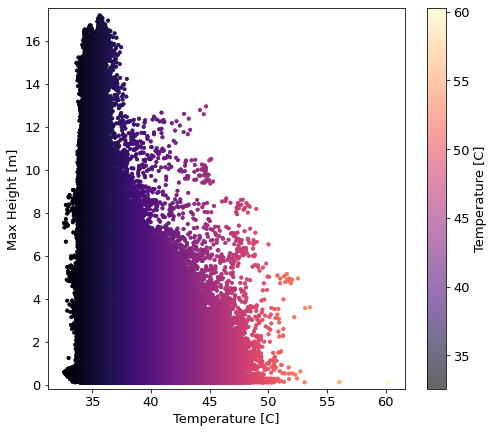

In [59]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()


a = ax.scatter(x=df_pixels_0p1m.Temperature,
               y=df_pixels_0p1m.Height,
               c=df_pixels_0p1m.Temperature,
               alpha=0.6, cmap='magma', s=15, marker='o', edgecolors='none'
              )

fig.colorbar(a, label='Temperature [C]')

ax.set_ylim(-0.2, 17.5)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Max Height [m]')

fig.savefig(f'./figs/LidarComparisons/ScatterPlot_TempxHeight_{projstr}.jpg', dpi=300)

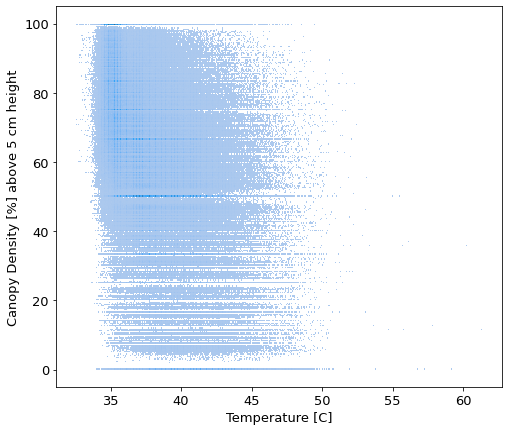

In [60]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

sns.histplot(data=df_pixels, x=f'Temperature', y='CanopyDensityPercent', ax=ax)

ax.set_ylim(-5, 105)
ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Canopy Density [%] above 5 cm height')

fig.savefig(f'./figs/LidarComparisons/HistPlot_TempxCanopyDensity_{projstr}.jpg', dpi=300)

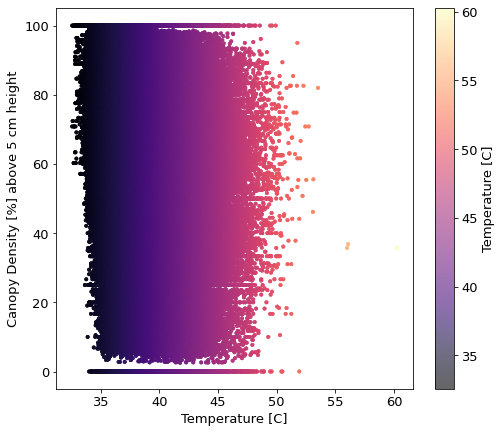

In [61]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

df_pixels_0p1m = df_pixels.loc[df_pixels.Height >= 0.1]

a = ax.scatter(x=df_pixels_0p1m.Temperature,
               y=df_pixels_0p1m.CanopyDensity*100,
               c=df_pixels_0p1m.Temperature,
               alpha=0.6, cmap='magma', s=15, marker='o', edgecolors='none'
              )

fig.colorbar(a, label='Temperature [C]')

ax.set_ylim(-5, 105)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Canopy Density [%] above 5 cm height')

fig.savefig(f'./figs/LidarComparisons/ScatterPlot_TempxCanopyDensity_{projstr}.jpg', dpi=300)

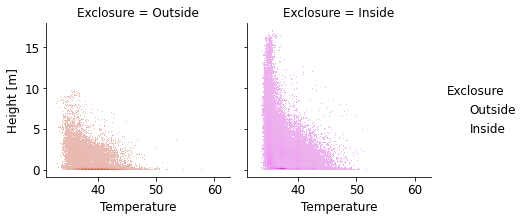

In [62]:
# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [16, 14]
plt.rcParams.update({'font.size': 12})

# fig, ax = plt.subplots()

# sns.histplot(data=df_pixels, x=f'Temperature', y='Height', hue='Exset_xlim,
#              palette='plasma_r', hue_order=exclosure_hues, ax=ax)

# Use to dataframe to plot scatterplots of height v temp on a grid
FG = sns.FacetGrid(data=df_pixels, col='Exclosure', hue='Exclosure',
                   palette='plasma_r', hue_order=exclosure_hues)

FG.map_dataframe(sns.histplot, x=f'Temperature', y='Height')

FG.set_xlabels(f'Temperature')
FG.set_ylabels('Height [m]')
    
FG.add_legend()
# FG.tight_layout()

FG.savefig(f'./figs/LidarComparisons/DisPlot_TempvHeight_Exclosure_{projstr}.jpg', dpi=300)

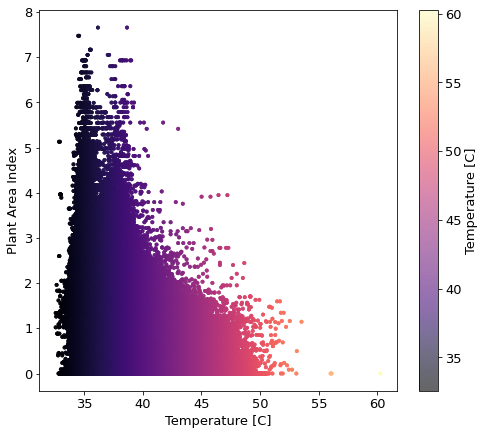

In [63]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

df_pixels_0p1m = df_pixels.loc[df_pixels.Height >= 0.1]

a = ax.scatter(x=df_pixels_0p1m.Temperature,
               y=df_pixels_0p1m.PAI,
               c=df_pixels_0p1m.Temperature,
               alpha=0.6, cmap='magma', s=15, marker='o', edgecolors='none'
              )

fig.colorbar(a, label='Temperature [C]')

# ax.set_ylim(-0.1, 1.5)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Plant Area Index')

fig.savefig(f'./figs/LidarComparisons/ScatterPlot_TempxPAI_{projstr}.jpg', dpi=300)

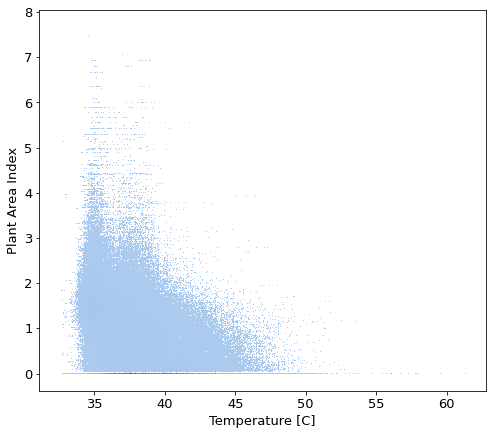

In [64]:
# df_pixels['CanopyDensityPercent'] = df_pixels.CanopyDensity*100
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

sns.histplot(data=df_pixels, x=f'Temperature', y='PAI', ax=ax)

# ax.set_ylim(-0.1, 1.5)
ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Plant Area Index')

fig.savefig(f'./figs/LidarComparisons/HistPlot_TempxPAI_{projstr}.jpg', dpi=300)

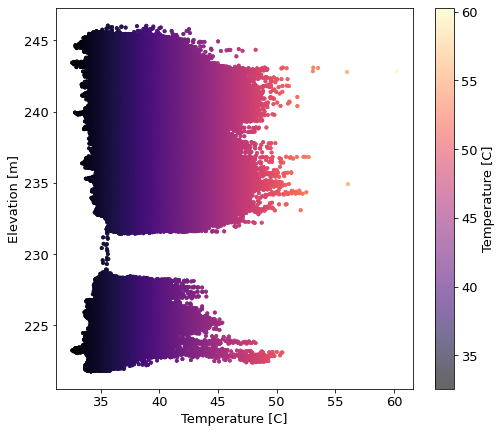

In [65]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()


a = ax.scatter(x=df_pixels_0p1m.Temperature,
               y=df_pixels_0p1m.Elevation,
               c=df_pixels_0p1m.Temperature,
               alpha=0.6, cmap='magma', s=15, marker='o', edgecolors='none'
              )

fig.colorbar(a, label='Temperature [C]')

# ax.set_ylim(-0.2, 17.5)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Elevation [m]')

fig.savefig(f'./figs/LidarComparisons/ScatterPlot_TempxElevation_{projstr}.jpg', dpi=300)

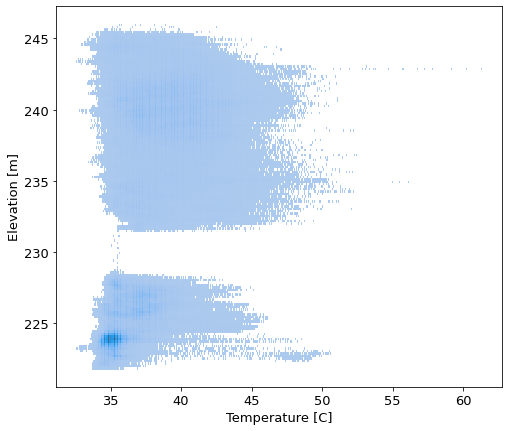

In [66]:
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

sns.histplot(data=df_pixels, x=f'Temperature', y='Elevation', ax=ax)

# ax.set_ylim(-0.1, 1.5)
ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Elevation [m]')

fig.savefig(f'./figs/LidarComparisons/HistPlot_TempxElevation_{projstr}.jpg', dpi=300)

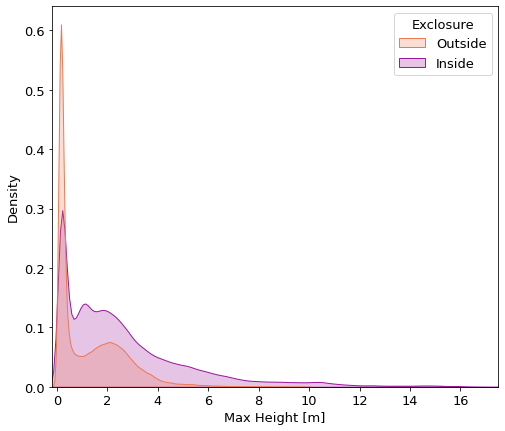

In [67]:
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

sns.kdeplot(data=df_pixels_0p1m, x='Height', hue='Exclosure', ax=ax, palette='plasma_r',
            fill=True, hue_order=exclosure_hues)

ax.set_xlabel('Max Height [m]')
ax.set_xlim(-0.2, 17.5)
fig.savefig(f'./figs/LidarComparisons/KDEplot_HeightbyExclosure_{projstr}.jpg', dpi=300)

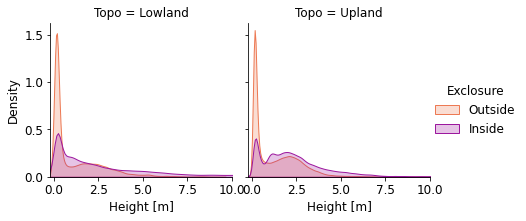

In [68]:
# Split by Lowland and Upland FacetGrid
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams.update({'font.size': 12})

# Use to dataframe to plot scatterplots of height v temp on a grid
FG = sns.FacetGrid(data=df_pixels_0p1m, col='Topo', hue='Exclosure',
                   palette='plasma_r', hue_order=exclosure_hues)

FG.map_dataframe(sns.kdeplot, x='Height', fill=True)

FG.set_xlabels(f'Height [m]')
    
FG.set_ylabels('Density')
FG.add_legend()
# FG.tight_layout()
FG.set(xlim=(-0.2, 10))

FG.savefig(f'./figs/LidarComparisons/KDEplot_HeightbyExclosureandTopo_{projstr}.jpg', dpi=300)

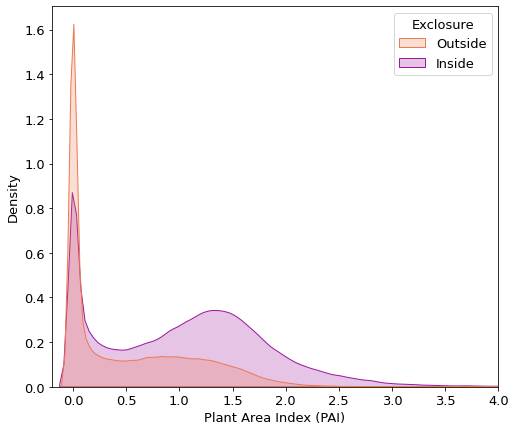

In [69]:
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

sns.kdeplot(data=df_pixels_0p1m, x='PAI', hue='Exclosure', ax=ax, palette='plasma_r',
            fill=True, hue_order=exclosure_hues)

ax.set_xlabel('Plant Area Index (PAI)')
ax.set_xlim(-0.2, 4)
fig.savefig(f'./figs/LidarComparisons/KDEplot_PAIbyExclosure_{projstr}.jpg', dpi=300)

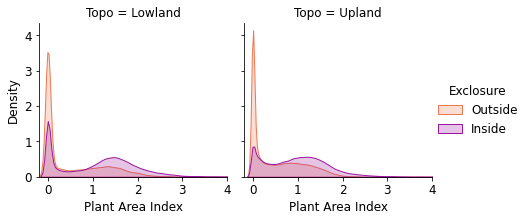

In [70]:
# Split by Lowland and Upland FacetGrid
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams.update({'font.size': 12})

# Use to dataframe to plot scatterplots of height v temp on a grid
FG = sns.FacetGrid(data=df_pixels_0p1m, col='Topo', hue='Exclosure',
                   palette='plasma_r', hue_order=exclosure_hues)

FG.map_dataframe(sns.kdeplot, x='PAI', fill=True)

FG.set_xlabels('Plant Area Index')
    
FG.set_ylabels('Density')
    
FG.add_legend()
FG.set(xlim=(-0.2, 4))

FG.savefig(f'./figs/LidarComparisons/KDEplot_CanopyDensitybyExclosureandTopo_{projstr}.jpg', dpi=300)

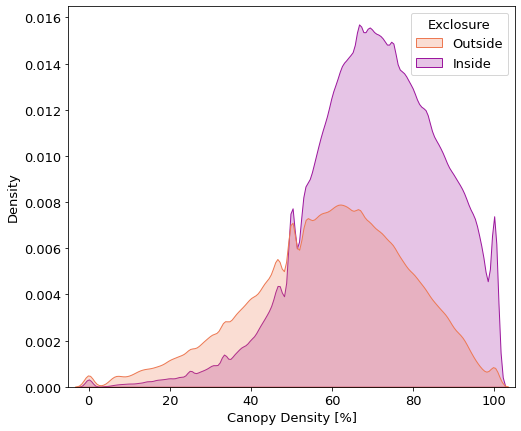

In [71]:
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

sns.kdeplot(data=df_pixels_0p1m, x='CanopyDensityPercent',
            hue='Exclosure', ax=ax, palette='plasma_r',
            fill=True, hue_order=exclosure_hues)

ax.set_xlabel('Canopy Density [%]')
ax.set_xlim(-5, 105)
fig.savefig(f'./figs/LidarComparisons/KDEplot_CanopyDensitybyExclosure_{projstr}.jpg', dpi=300)

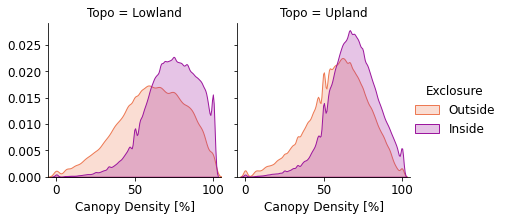

In [77]:
# Split by Lowland and Upland FacetGrid
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams.update({'font.size': 12})

# Use to dataframe to plot scatterplots of height v temp on a grid
FG = sns.FacetGrid(data=df_pixels_0p1m, col='Topo', hue='Exclosure',
                   palette='plasma_r', hue_order=exclosure_hues)

FG.map_dataframe(sns.kdeplot, x='CanopyDensityPercent', fill=True)

FG.set_xlabels('Canopy Density [%]')
    
FG.add_legend()
FG.set(xlim=(-5, 105))

FG.savefig(f'./figs/LidarComparisons/KDEplot_CanopyDensitybyExclosureandTopo_{projstr}.jpg',
           dpi=300)

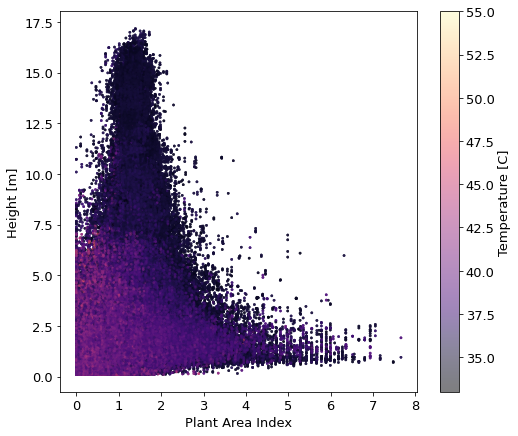

In [84]:
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})


fig, ax = plt.subplots()


a = ax.scatter(y=df_pixels_0p1m.Height,
               x=df_pixels_0p1m.PAI,
               c=df_pixels_0p1m.Temperature,
               alpha=0.5, cmap='magma', s=7, marker='o', edgecolors='none', vmin=33, vmax=55
              )

fig.colorbar(a, label='Temperature [C]')

# ax.set_ylim(-0.2, 17.5)

ax.set_xlabel('Plant Area Index')
ax.set_ylabel('Height [m]')

fig.savefig(f'./figs/LidarComparisons/Scatterplot_PAIxHeight_TempColor_{projstr}.jpg',
           dpi=300)


#### NOTE: The Below GGST plots and stats need to be reworked
##### 12/1/22
Just to go with new vegtype column (before using a pixel based method)

In [29]:
# for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
#     fig, (ax1, ax2) = plt.subplots(1,2)
    
#     # Plot Upland and Lowland in seperate Columns
#     for ul, ax in zip(['Lowland', 'Upland'], [ax1, ax2]):

#         sns.displot(data=df_pixels.loc[df_pixels['Topo']==ul],
#                     x=f'Temperature_{ggst}',
#                     hue='Exclosure',
#                     ax=ax, 
#                     palette='plasma_r',
#                     hue_order=exclosure_hues,
#                     fill=True)

#         ax.set_title(f'{ul}')

#     fig.tight_layout()

#     fig.savefig(f'./figs/KDEPlot_Exclosure_{ggst}_UpLowSplit_{projstr}.jpg', dpi=300)

In [30]:
# for ggst in ['ground', 'grass', 'shrub', 'tree']:
    

#     # Use to dataframe to plot scatterplots of height v temp on a grid
#     FG = sns.FacetGrid(data=df_pixels, col='imgf', row='Exclosure', hue='Exclosure',
#                        palette='plasma_r', hue_order=exclosure_hues)

#     FG.map_dataframe(sns.histplot, x=f'Temperature_{ggst}', y='Height')
    
#     FG.add_legend()
#     FG.tight_layout()

#     FG.set_xlabels(f'Temperature of {ggst}')
#     FG.set_ylabels('Height [m]')

#     FG.savefig(f'./figs/ScatterPlot_TempvHeight_Exclosure_{ggst}_FacetGrid_{projstr}_{imgf}.jpg', dpi=300)

## Print Statistics and Plot

In [31]:
nLow = df_pixels.Topo.loc[df_pixels.Topo=='Lowland'].shape[0]
nUp = df_pixels.Topo.loc[df_pixels.Topo=='Upland'].shape[0]
print(f'Lowland: {nLow}, Upland: {nUp}')

nFull = df_pixels.Topo.loc[df_pixels.Exclosure=='Inside'].shape[0]
nOpen = df_pixels.Topo.loc[df_pixels.Exclosure=='Outside'].shape[0]
print(f'Open: {nOpen}, Full: {nFull}')

Lowland: 1814208, Upland: 2882916
Open: 2102064, Full: 2595060


In [32]:
df_stats = df_pixels.groupby(['imgf', 'Topo', 'Exclosure']).describe()
df_stats.to_csv(f'./data/out/{projstr}_stats.csv')

In [33]:
df_pixels.groupby(['imgf', 'Topo', 'Exclosure']).mean()

Temperature    Height  \
imgf                          Topo    Exclosure                          
Flight2_cam1-000-000201-0.tif Lowland Inside       35.880787  2.744672   
                                      Outside      37.553524  0.599969   
Flight2_cam1-001-000217-0.tif Upland  Inside       38.515957  2.789519   
                                      Outside      39.545078  0.946942   
Flight2_cam1-001-000301-0.tif Upland  Inside       39.442360  2.053818   
                                      Outside      38.893181  1.065955   
Flight2_cam1-002-000147-0.tif Upland  Inside       37.876381  1.885295   
                                      Outside      39.045162  0.788678   

                                                  Elevation  CanopyDensity  \
imgf                          Topo    Exclosure                              
Flight2_cam1-000-000201-0.tif Lowland Inside     224.788651       0.702955   
                                      Outside    225.858444       0.421133   
Flight2_cam1-001-000217-0.tif Upland  Inside     234.469589       0.648529   
                                      Outside    238.063522       0.518680   
Flight2_cam1-001-000301-0.tif Upland  Inside     239.897751       0.673836   
                                      Outside    243.111221       0.517654   
Flight2_cam1-002-000147-0.tif Upland  Inside     240.042450       0.663911   
                                      Outside    241.122452       0.440704   

                                                      PAI  \
imgf                          Topo    Exclosure             
Flight2_cam1-000-000201-0.tif Lowland Inside     1.036846   
                                      Outside    0.256112   
Flight2_cam1-001-000217-0.tif Upland  Inside     1.075545   
                                      Outside    0.385804   
Flight2_cam1-001-000301-0.tif Upland  Inside     0.878946   
                                      Outside    0.398761   
Flight2_cam1-002-000147-0.tif Upland  Inside     0.941800   
                                      Outside    0.308475   

                                                 CanopyDensityPercent  
imgf                          Topo    Exclosure                        
Flight2_cam1-000-000201-0.tif Lowland Inside                70.295518  
                                      Outside               42.113257  
Flight2_cam1-001-000217-0.tif Upland  Inside                64.852918  
                                      Outside               51.867999  
Flight2_cam1-001-000301-0.tif Upland  Inside                67.383643  
                                      Outside               51.765353  
Flight2_cam1-002-000147-0.tif Upland  Inside                66.391096  
                                      Outside               44.070357

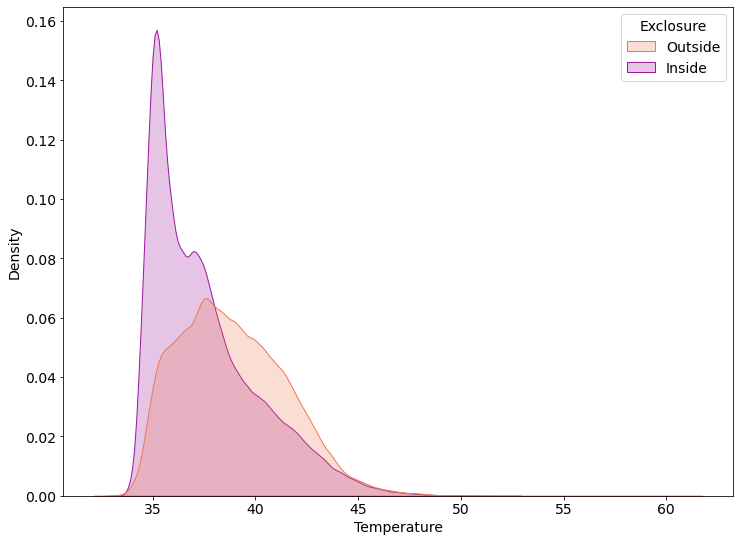

In [34]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots()
sns.kdeplot(data=df_pixels, x='Temperature', hue='Exclosure', ax=ax, palette='plasma_r',
            fill=True, hue_order=exclosure_hues)
fig.savefig(f'./figs/KDEplot_Exclosure_{projstr}.jpg', dpi=300)

ValueError: Could not interpret value `Temperature_ground` for parameter `x`

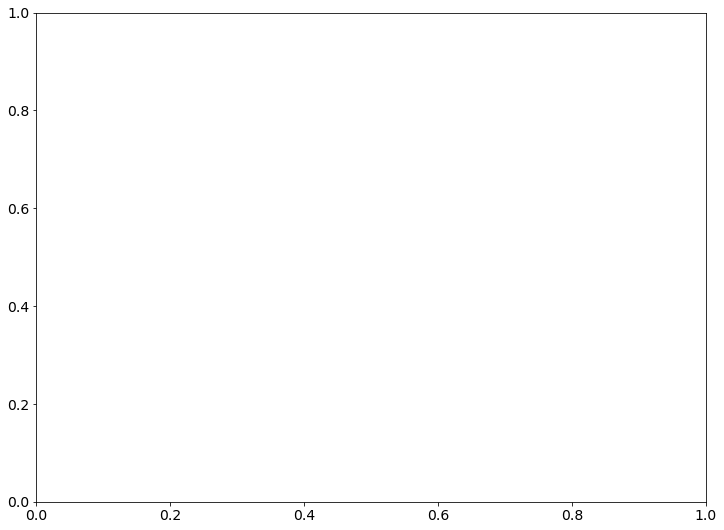

In [35]:
# Ground, grass, shrub, tree plots
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 14})

for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
    fig, ax = plt.subplots()
    
    sns.kdeplot(data=df_pixels, x=f'Temperature_{ggst}', hue='Exclosure', ax=ax, palette='plasma_r',
                fill=True, hue_order=exclosure_hues)
    fig.savefig(f'./figs/KDEplot_Exclosure_{ggst}_{projstr}.jpg', dpi=300)

In [ ]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots()
sns.kdeplot(data=df_pixels, x='Temperature', hue='Topo', ax=ax, palette='viridis_r',
            fill=True, hue_order=topo_hues)
fig.savefig(f'./figs/KDEplot_Topo_{projstr}.jpg', dpi=300)

In [ ]:
for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
    fig, ax = plt.subplots()
    
    sns.kdeplot(data=df_pixels, x=f'Temperature_{ggst}', hue='Topo', ax=ax, palette='viridis_r',
                fill=True, hue_order=topo_hues)
    
    fig.savefig(f'./figs/KDEplot_Topo_{ggst}_{projstr}.jpg', dpi=300)

In [ ]:
# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams.update({'font.size': 10})

# Use to dataframe to plot KDE plots in a facetgrid
FG = sns.FacetGrid(data=df_pixels, col='imgf', hue='Exclosure', palette='plasma_r', col_wrap=4, hue_order=exclosure_hues)
FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
FG.add_legend()
FG.tight_layout()
# ax.legend()
FG.set_xlabels(f'Temperature')
FG.set_ylabels(f'Density')

FG.savefig(f'./figs/KDEPlot_Exclosure_FacetGrid_{projstr}_landscape.jpg', dpi=300)

In [ ]:
for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
    # Use to dataframe to plot KDE plots in a facetgrid
    FG = sns.FacetGrid(data=df_pixels, col='imgf', hue='Exclosure', 
                       palette='plasma_r', col_wrap=4, hue_order=exclosure_hues)
    
    FG.map_dataframe(sns.kdeplot, x=f'Temperature_{ggst}', fill=True)
    
    FG.add_legend()
    FG.tight_layout()
    
    FG.set_xlabels(f'Temperature of {ggst}')
    FG.set_ylabels('Density')

    FG.savefig(f'./figs/KDEPlot_Exclosure_{ggst}_FacetGrid_{projstr}_landscape.jpg', dpi=300)

In [ ]:
# Use to dataframe to plot KDE plots in a facetgrid
# sns.kdeplot(pixel_dict['pixels_xr'][ID][idx].data.flatten()-273.15, ax=ax)
# FG = sns.FacetGrid(data=df_pixels, col='Exclosure',  row='imgf')
# FG = sns.FacetGrid(data=df_pixels, row='Topo', col='imgf',  hue='Exclosure', palette='plasma_r', hue_order=exclosure_hues)
# FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
# FG.add_legend()
# # ax.legend()

# FG.savefig(f'./figs/KDEPlot_Topo_FacetGrid_{projstr}_landscape.jpg', dpi=300)

In [ ]:
# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams.update({'font.size': 10})

# Plot Upland and Lowland in seperate Columns
for ul in ['Lowland', 'Upland']:
    
    # Use to dataframe to plot KDE plots in a facetgrid
    FG = sns.FacetGrid(data=df_pixels.loc[df_pixels['Topo']==ul], col='imgf',  hue='Exclosure', palette='plasma_r', col_wrap=4, hue_order=exclosure_hues)
    FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
    FG.add_legend()
    
    FG.tight_layout()
    # ax.legend()

    FG.savefig(f'./figs/KDEPlot_{ul}_FacetGrid_{projstr}_landscape.jpg', dpi=300)

In [ ]:
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams.update({'font.size': 14})
fig, (ax1, ax2) = plt.subplots(1,2)
# fig.savefig('./figs/KDEplot_Exclosure_Nkuhlu.jpg', dpi=300)

# Plot Upland and Lowland in seperate Columns
for ul, ax in zip(['Lowland', 'Upland'], [ax1, ax2]):
    
    sns.kdeplot(data=df_pixels.loc[df_pixels['Topo']==ul],
                x='Temperature',
                hue='Exclosure',
                ax=ax, 
                palette='plasma_r',
                hue_order=exclosure_hues,
                fill=True)
                                   
    ax.set_title(f'{ul}')
    
fig.tight_layout()

fig.savefig(f'./figs/KDEPlot_Exclosure_UpLowSplit_{projstr}.jpg', dpi=300)

In [ ]:
for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
    fig, (ax1, ax2) = plt.subplots(1,2)
    
    # Plot Upland and Lowland in seperate Columns
    for ul, ax in zip(['Lowland', 'Upland'], [ax1, ax2]):

        sns.kdeplot(data=df_pixels.loc[df_pixels['Topo']==ul],
                    x=f'Temperature_{ggst}',
                    hue='Exclosure',
                    ax=ax, 
                    palette='plasma_r',
                    hue_order=exclosure_hues,
                    fill=True)

        ax.set_title(f'{ul}')

    fig.tight_layout()

    fig.savefig(f'./figs/KDEPlot_Exclosure_{ggst}_UpLowSplit_{projstr}.jpg', dpi=300)

In [ ]:
# Newly added 7/25 boxplot by image
plt.rcParams['figure.figsize'] = [15, 9]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()
sns.boxplot(data=df_pixels,
            x='imgf', y='Temperature', hue='Exclosure',
            ax=ax, palette='plasma_r', hue_order=exclosure_hues)
plt.xticks(rotation=90, ha='right')

fig.savefig(f'./figs/BoxplotByImage_Exclosure_{projstr}.jpg', dpi=300)

In [ ]:
# Newly added 7/25 boxplot by image
plt.rcParams['figure.figsize'] = [15, 9]
plt.rcParams.update({'font.size': 13})

for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
    fig, ax = plt.subplots()
    sns.boxplot(data=df_pixels,
                x='imgf', y=f'Temperature_{ggst}', hue='Exclosure',
                ax=ax, palette='plasma_r', hue_order=exclosure_hues)
    plt.xticks(rotation=90, ha='right')

    fig.savefig(f'./figs/BoxplotByImage_Exclosure_{ggst}_{projstr}.jpg', dpi=300)